# Prerequisites

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# plt.rcParams['mathtext.fontset'] = 'custom'
# plt.rcParams['mathtext.rm'] = 'Times New Roman'
# plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
# plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'

from pathlib import Path
data_root = Path('../data')

import sys
sys.path.append('../')

import utils_functionality.velocity_calculation as vc
import utils_functionality.sedimentation_calculation as sc
from utils_functionality.model_analysis import extract_agg_features;

# from utils_functionality.models.modelling3_utils import _add_sedimentation_sign

sns.set_style('darkgrid')
plt.rcParams['figure.dpi'] = 200
plt.rcParams["font.family"] = "Times New Roman"
sns.set_theme(rc={"font.family": "Times New Roman"})

In [2]:
# import matplotlib.font_manager
# display(matplotlib.font_manager.findSystemFonts(fontpaths=None, fontext='ttf'))  # Uncomment this to list all fonts


# Update main_df

df_main.xlsx before drag force update is used to get updated df_main.xlsx dataset

In [3]:
df_main_dragless = pd.read_excel(
    Path(data_root, 'before_drag_force_update', 'df_main.xlsx')
)
df_main = df_main_dragless.copy(deep=True)
df_main_dragless.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 30 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   test                             372 non-null    int64  
 1   net_impact                       372 non-null    int64  
 2   splashing                        372 non-null    int64  
 3   splashing_spectrum               372 non-null    int64  
 4   breaking_up                      372 non-null    int64  
 5   rebound                          372 non-null    int64  
 6   one_drop                         372 non-null    int64  
 7   voltage                          372 non-null    float64
 8   long_impulse_duration            372 non-null    int64  
 9   long_impulse_dur_binary          372 non-null    object 
 10  wettability                      372 non-null    object 
 11  roughness                        372 non-null    float64
 12  liquid_density        

## no_fragmentation and K-Parameter

In [4]:
df_main = df_main.rename(
    {
        'net_impact': 'no_fragmentation',
        'We_Re': 'K',
    },
    axis=1,
)
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 30 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   test                             372 non-null    int64  
 1   no_fragmentation                 372 non-null    int64  
 2   splashing                        372 non-null    int64  
 3   splashing_spectrum               372 non-null    int64  
 4   breaking_up                      372 non-null    int64  
 5   rebound                          372 non-null    int64  
 6   one_drop                         372 non-null    int64  
 7   voltage                          372 non-null    float64
 8   long_impulse_duration            372 non-null    int64  
 9   long_impulse_dur_binary          372 non-null    object 
 10  wettability                      372 non-null    object 
 11  roughness                        372 non-null    float64
 12  liquid_density        

## Volume fraction

We will add info about time without mixing `no_mixing_time` in seconds.

Then, we will save `volume_fraction` as `init_volume_fraction`. 

Then, evaluation of actual volume fraction will be saved in `volume_fraction`.

Also, terminal velocity of particles in suspensions will be saved in `sedimentation_velocity`.

### Create 'no_mixing_time' in main dataframe

In [5]:
df_protocol = pd.read_excel(
    Path(data_root, 'archive', 'suspension_experiments.xlsx'),
    usecols='A:E'
)
df_protocol.columns = [
    'test',
    'substrate',
    'suspension',
    'time_start',
    'time_end',
]
df_protocol = (
    df_protocol[
        df_protocol['test'].isin(df_main['test'])
    ]
    .reset_index(drop=True)
)

for column in ['time_start', 'time_end']:
    df_protocol.loc[
        df_protocol[column].str.contains('-', na=False), 
        column
    ] = None

    df_protocol[column] = pd.to_datetime(
        df_protocol[column], 
        format='%H:%M:%S',
    )

df_protocol['no_mixing_time'] = (
    (df_protocol['time_end'] - df_protocol['time_start'])
    .dt.total_seconds()
)

nan_cnt = df_protocol["no_mixing_time"].isna().sum()
print(
    f'Number of NaNs before filling: {nan_cnt}'
)
print('Description of no_mixing_time before filling')
display(df_protocol['no_mixing_time'].describe())
# Fill NaNs based on suspension code: assume, 
# that medium no-mixing time for the same suspension is the same
df_protocol['no_mixing_time'] = (
    df_protocol.groupby(by='suspension')['no_mixing_time'].transform(
        lambda x: x.fillna(x.median())
    )
)
print('Description of no_mixing_time after filling')
display(df_protocol['no_mixing_time'].describe())

df_main['no_mixing_time'] = df_protocol['no_mixing_time']
print('Description of no_mixing_time in main dataframe')
display(df_main['no_mixing_time'].describe())

nan_cnt = df_main["no_mixing_time"].isna().sum()
print(f'Number of NaNs after filling: {nan_cnt}')

# save `volume_fraction` as `init_volume_fraction`. 
df_main['init_volume_fraction'] = df_main['volume_fraction']

Number of NaNs before filling: 12
Description of no_mixing_time before filling


count    360.000000
mean      85.127778
std       55.902724
min       27.000000
25%       50.000000
50%       66.000000
75%      100.250000
max      457.000000
Name: no_mixing_time, dtype: float64

Description of no_mixing_time after filling


count    372.000000
mean      84.795699
std       55.067368
min       27.000000
25%       50.000000
50%       66.000000
75%       99.250000
max      457.000000
Name: no_mixing_time, dtype: float64

Description of no_mixing_time in main dataframe


count    372.000000
mean      84.795699
std       55.067368
min       27.000000
25%       50.000000
50%       66.000000
75%       99.250000
max      457.000000
Name: no_mixing_time, dtype: float64

Number of NaNs after filling: 0


### Save volume fraction estimation, terminal velocity, sedimentation Re

In [6]:
df_main.columns

Index(['test', 'no_fragmentation', 'splashing', 'splashing_spectrum',
       'breaking_up', 'rebound', 'one_drop', 'voltage',
       'long_impulse_duration', 'long_impulse_dur_binary', 'wettability',
       'roughness', 'liquid_density', 'surface_tension', 'viscosity',
       'particle_mean_diameter', 'particle_density', 'volume_fraction',
       'droplet_diameter', 'height', 'inclination', 'roughness_binary',
       'particle_liquid_density_ratio', 'volume_fraction_binary',
       'particle_diameter_cat', 'particle_droplet_diameter_ratio', 'velocity',
       'Re', 'We', 'K', 'no_mixing_time', 'init_volume_fraction'],
      dtype='object')

In [7]:
# Then, evaluation of actual volume fraction will be saved in `volume_fraction`.
# Also, terminal velocity of particles in suspensions will be saved in `sedimentation_velocity`.

def get_drop_volume_fraction(row):
    phi_drop_term, v_term, sedimentation_Re = sc.get_drop_volume_fraction(
        time=row['no_mixing_time'],
        density_liquid=row['liquid_density'],
        viscosity_liquid=row['viscosity'],
        particle_mean_diameter=row['particle_mean_diameter'],
        particle_liquid_density_ratio=row['particle_liquid_density_ratio'],
        init_volume_fraction=row['init_volume_fraction'],
        droplet_diameter=row['droplet_diameter'],
        # verbose=True,
    )
    
    row['volume_fraction'] = phi_drop_term[0]
    row['sedimentation_velocity'] = v_term
    row['sedimentation_Re'] = sedimentation_Re[0]
    return row

# Vertical velocity with drag force
df_main = df_main.apply(
    get_drop_volume_fraction,
    axis=1
)

print('Volume fraction stats')
display(
    df_main[['init_volume_fraction', 'volume_fraction']].describe()
)
print('Relative volume fraction difference')
display(
    (np.abs(df_main['init_volume_fraction'] - df_main['volume_fraction'])\
        /df_main['init_volume_fraction']).describe()
)

Volume fraction stats


,init_volume_fraction,volume_fraction
count,372.000000,372.000000
mean,0.073952,0.076141
std,0.020020,0.024074
min,0.040000,0.028755
25%,0.050000,0.048587
50%,0.080000,0.080282
75%,0.080000,0.089212
max,0.100000,0.235561


Relative volume fraction difference


count    372.000000
mean       0.109805
std        0.173675
min        0.000000
25%        0.003568
50%        0.046240
75%        0.160146
max        1.944518
dtype: float64

In [8]:
df_main[df_main['volume_fraction'] >= 0.13].T

,226,227,228,261,301,369
test,249,250,251,285,325,393
no_fragmentation,1,1,1,0,0,0
splashing,0,0,0,1,1,1
splashing_spectrum,0,0,0,2,1,1
breaking_up,0,0,0,0,0,0
rebound,0,0,1,0,0,0
one_drop,0,1,1,0,0,1
voltage,107.0,107.0,107.0,106.0,108.0,107.0
long_impulse_duration,15,15,15,15,12,12
long_impulse_dur_binary,high,high,high,high,low,low


There is an outlier - test 227, since no_mixing_time was very long!

## Stokes number and Sedimentation Reynolds with sign

**Stokes number** is a dimensionless parameter that characterizes the behavior of particles suspended in a fluid flow. It is defined as the ratio of the particle's characteristic time to the characteristic time scale of the flow (see derivations in Obsidian - `Sedimentation model. V3!`)

$$
\text{Stk} = \frac{\rho_\text{p}d^2_\text{p}|v_\text{term}|}{18\mu_\text{l}D_\text{drop}}
$$

Also, let us add sign to the `sedimentation_Re` -> `sign_sedimentation_Re`:
$$
\text{Re}_\text{sign,sediment} = \text{sign}(v_\text{term})\cdot \frac{|v_\text{term}|d_\text{p}\rho_\text{l}}{\mu_\text{l}}
$$

In [9]:
def get_stokes_number(row):
    
    rho_p = row['particle_density']
    d_p = row['particle_mean_diameter']
    v_term = row['sedimentation_velocity']
    mu_l = row['viscosity']
    D_drop = row['droplet_diameter']
    
    Stk = (
        (rho_p*d_p**2*abs(v_term))
        /(18*mu_l*D_drop)
    )
    return Stk

# # Add sign
# def get_sedimentation_sign(row, column='sedimentation_Re'):
#     sign_column = 'sign_'+column
#     row[sign_column] = row[column]
#     if row['sedimentation_velocity'] < 0.:
#         row[sign_column] *= -1
#     return row

# Add signs
def get_sedimentation_signs(row, columns):
    for column in columns:
        sign_column = 'sign_'+column
        row[sign_column] = row[column]
        if row['particle_liquid_density_ratio'] < 1.:
            row[sign_column] *= -1
    return row

# Vertical velocity with drag force
df_main = df_main.apply(
    get_drop_volume_fraction,
    axis=1
)

df_main['sedimentation_Stk'] = df_main.apply(
    get_stokes_number,
    axis=1,
)

df_main = df_main.apply(
    get_sedimentation_signs,
    axis=1,
    args=(
        [
            'sedimentation_Re',
            'sedimentation_Stk',
            'particle_droplet_diameter_ratio',
        ],
    )
)

print('Sedimentation Stokes number and sign_sedimentation_Re stats')

df_main[['sedimentation_Re', 'sign_sedimentation_Re', 'sedimentation_Stk']].describe().apply(lambda s: s.apply('{:,.3e}'.format))

Sedimentation Stokes number and sign_sedimentation_Re stats


,sedimentation_Re,sign_sedimentation_Re,sedimentation_Stk
count,3.720e+02,3.720e+02,3.720e+02
mean,9.673e-05,3.555e-05,2.972e-07
std,1.505e-04,1.754e-04,6.279e-07
min,0.000e+00,-4.872e-04,0.000e+00
25%,1.265e-06,-1.050e-05,8.923e-10
50%,1.050e-05,0.000e+00,7.525e-09
75%,9.158e-05,5.387e-05,1.038e-07
max,4.872e-04,4.307e-04,2.216e-06


## Droplet density

We will use this density only for droplet mass calculation.
For impact only liquid density is used.

$\rho_\text{d} = \phi \rho_\text{p} + (1 - \phi) \rho_\text{l}$

where $\phi$ is a particle volume fraction

In [10]:
df_main['droplet_density'] = (
    df_main['volume_fraction'] * df_main['particle_density']
    + (1 - df_main['volume_fraction']) * df_main['liquid_density']
)
print('Densities stats')
display(
    df_main[['liquid_density', 'droplet_density']].describe()
)
print('Relative density difference')
display(
    (np.abs(df_main['liquid_density'] - df_main['droplet_density'])\
        /df_main['liquid_density']).describe()
)

Densities stats


,liquid_density,droplet_density
count,372.000000,372.000000
mean,1116.612903,1116.355849
std,99.672405,100.495122
min,820.000000,827.897253
25%,1000.000000,1000.000000
50%,1180.000000,1164.144977
75%,1180.000000,1181.613018
max,1180.000000,1301.174508


Relative density difference


count    372.000000
mean       0.009272
std        0.017565
min        0.000000
25%        0.000703
50%        0.001541
75%        0.011356
max        0.102690
dtype: float64

## Update velocities and inclination in rad

- `free_fall_velocity` - vertical impact velocity by gravity, but NO drag force
- `drag_velocity` - vertical impact velocity by gravity AND drag force
- `velocity` - normal to substrate component of `drag_velocity`.

Latter feature would be used to get `We` and `Re`, as well as `K`-parameter (`We_Re`)

In [11]:
def get_impact_velocity(row):
    impact_velocity = vc.get_impact_velocity(
        height=row['height'],
        drop_diameter=row['droplet_diameter'],
        drop_density=row['droplet_density']
    )
    return impact_velocity

df_main['free_fall_velocity'] = df_main['velocity']

# Vertical velocity with drag force
df_main['drag_velocity'] = df_main.apply(
    get_impact_velocity,
    axis=1
)

print('Velocities stats')
display(
    df_main[['free_fall_velocity', 'drag_velocity']].describe()
)
print('Relative velocities difference')
display(
    (np.abs(df_main['free_fall_velocity'] - df_main['drag_velocity'])\
        /df_main['drag_velocity']).describe()
)

Velocities stats


,free_fall_velocity,drag_velocity
count,372.000000,372.000000
mean,3.657667,3.452392
std,1.059988,0.921238
min,1.980571,1.932493
25%,3.961141,3.669942
50%,3.961141,3.750790
75%,3.961141,3.773536
max,5.941712,5.447130


Relative velocities difference


count    372.000000
mean       0.052782
std        0.028891
min        0.013638
25%        0.045654
50%        0.051835
75%        0.058841
max        0.190410
dtype: float64

Consider inclination.

VELOCITY is NORM-VELOCITY

In [12]:
df_main['inclination'] = np.deg2rad(df_main['inclination'])

df_main['velocity'] = (
    df_main['drag_velocity'] * np.cos(df_main['inclination'])
)

print('Norm Velocities stats')
display(
    df_main[['drag_velocity', 'velocity']].describe()
)
print('Relative norm. velocity difference')
display(
    (np.abs(df_main['drag_velocity'] - df_main['velocity'])\
        /df_main['velocity']).describe()
)

Norm Velocities stats


,drag_velocity,velocity
count,372.000000,372.000000
mean,3.452392,3.296870
std,0.921238,1.011054
min,1.932493,1.369482
25%,3.669942,2.647784
50%,3.750790,3.734172
75%,3.773536,3.767634
max,5.447130,5.447130


Relative norm. velocity difference


count    372.000000
mean       0.071075
std        0.144924
min        0.000000
25%        0.000000
50%        0.000000
75%        0.064178
max        0.414214
dtype: float64

### Re, We and K stats

In [13]:
def get_relative_diff(a, b):
    return (a - b)/a

features = ['Re', 'We', 'K']

df_main = extract_agg_features(df_main)

features_description = []

df_main_dragless = df_main_dragless.rename(
    {
        "We_Re": "K"
    },
    axis=1
)

for feature in features:
    features_description.append(
        get_relative_diff(
            df_main_dragless[feature], 
            df_main[feature]
        ).describe()
    )

print('Difference in Re, We, K')
display(pd.concat(features_description, axis=1))

print('Re, We, K')
display(df_main[['velocity', 'drag_velocity', 'Re', 'We', 'K']].describe())

Difference in Re, We, K


,Re,We,K
count,372.000000,372.000000,372.000000
mean,0.100079,0.181149,0.121894
std,0.094963,0.155523,0.112800
min,0.014543,0.028875,0.018146
25%,0.048717,0.095062,0.060521
50%,0.056941,0.110639,0.070662
75%,0.102651,0.194765,0.126624
max,0.351708,0.579717,0.418280


Re, We, K


,velocity,drag_velocity,Re,We,K
count,372.000000,372.000000,372.000000,372.000000,372.000000
mean,3.296870,3.452392,2948.084378,639.134182,150.955208
std,1.011054,0.921238,4223.861063,363.965370,73.612735
min,1.369482,1.932493,177.688828,82.786344,33.219599
25%,2.647784,3.669942,519.272865,326.931959,99.050948
50%,3.734172,3.750790,638.455200,675.178078,141.394709
75%,3.767634,3.773536,4521.230870,811.638245,211.021882
max,5.447130,5.447130,17139.003063,1835.683210,411.848360


## Relative roughness

count    372.000000
mean       0.000657
std        0.001101
min        0.000011
25%        0.000014
50%        0.000033
75%        0.000771
max        0.005113
Name: relative_roughness, dtype: float64

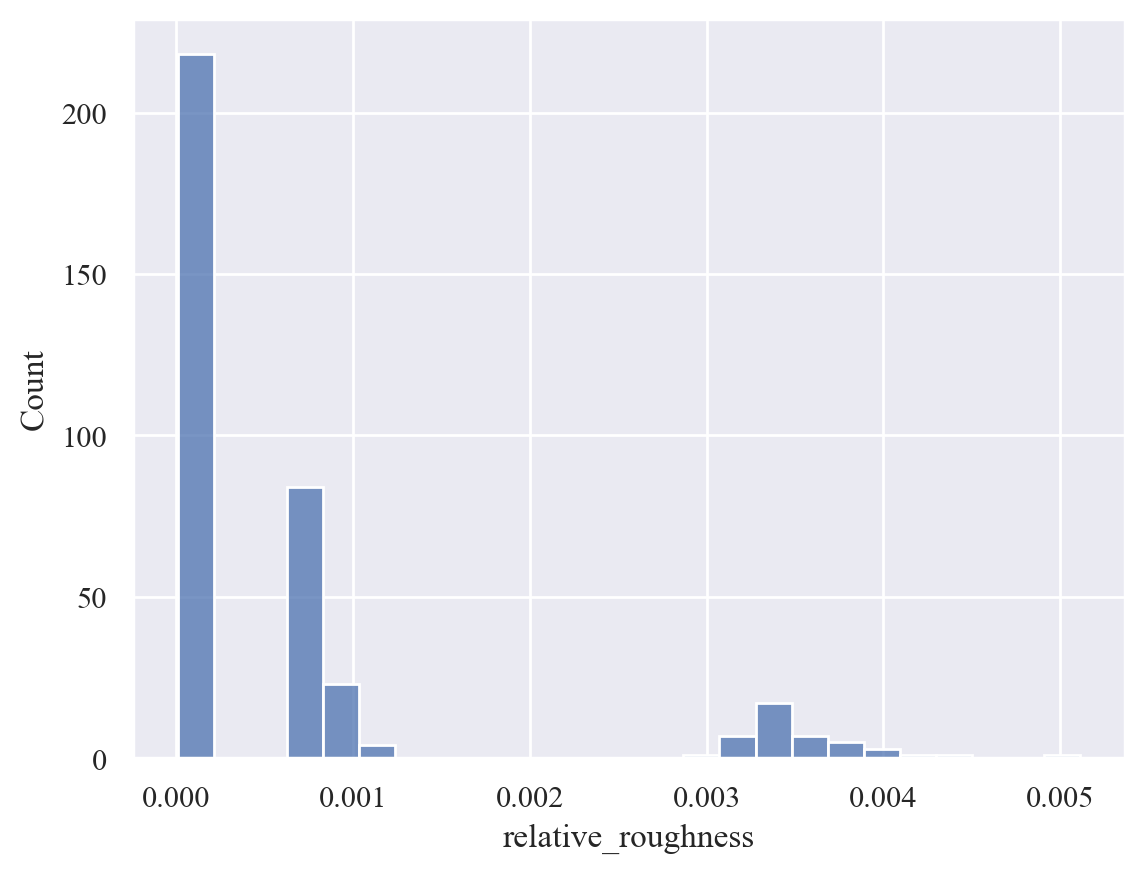

In [14]:
df_main['relative_roughness'] = df_main['roughness']*1e-6/df_main['droplet_diameter']
display(df_main['relative_roughness'].describe())

sns.histplot(
    data=df_main,
    x='relative_roughness',
);

# df_main['log_relative_roughness'] = np.log10(df_main['relative_roughness'])
# sns.histplot(
#     data=df_main,
#     x='log_relative_roughness'
# )

## Save main dataset

In [15]:
df_main.to_excel(Path(data_root, 'df_main.xlsx'), index=False)

## Labels:

- **splashing_spectrum**: 
    - **0 - no splashing**, when *'Number of detached small droplets during Spreading' == 0*
    - **1 - semi splashing**, when **gear** occurs, or when few droplets detach
    - **2 - splashing**. Pure splashing, when **many** droplets or **many small** droplets detach
    
- **splashing**: 1 - when *'Number of detached small droplets during Spreading' != 0*;
- **breaking_up**: when *'Number of detached small droplets during Receding or Rim merging' > 0*
- **rebound** consists of next cases:
    - **2 - true rebound**, when droplets detaching during partial rebound, or when droplet rebounds totally.
    
    *True rebound: 'Rebound' == 2 OR ('Rebound' == 1 AND 'Number of detached droplets during Rebound' > 0)*
    - **1 - jet ejection**, when true rebound does not appear.

    *'Rim merging or Central jet ejecting' == 2 AND NOT True rebound*    
    - **0** - no true rebound and no jet ejection. *Other cases*

-  **no_fragmentation** (ex. **net_impact** and **bulk_deformation**): when there is 
    - **no Splashing** (no small droplets detached during spreading, *'Number of detached small droplets during Spreading'==0*), 
    - **no Breaking up** (when *'Number of detached small droplets during Receding or Rim merging' == 0*)
    - **no True Rebound** (see True rebound definition early)

### Labels correlation

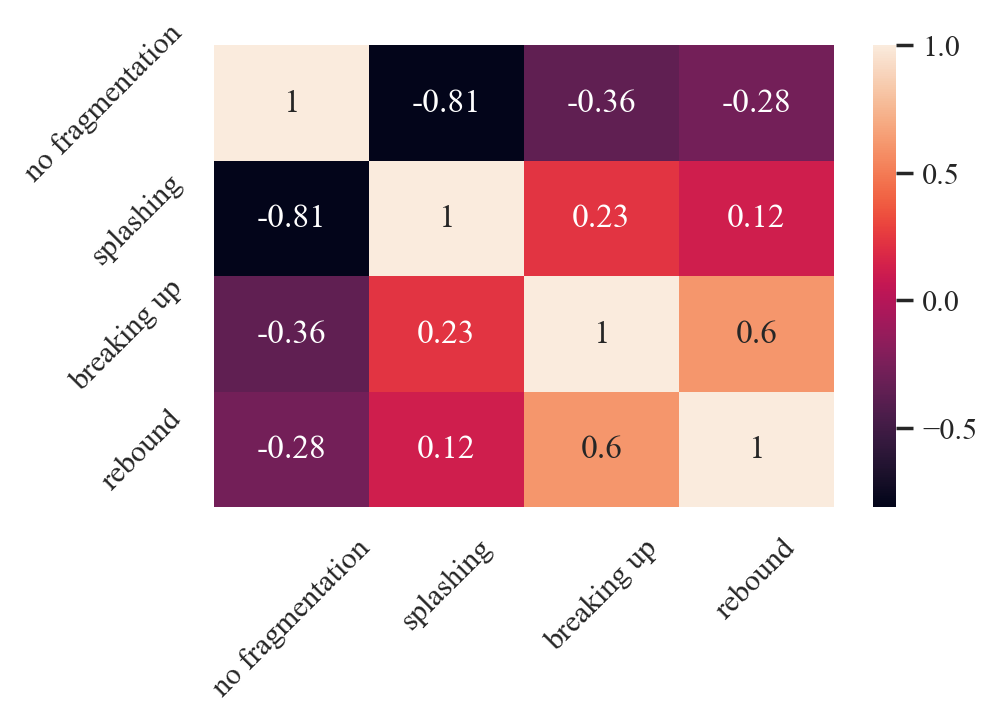

In [16]:
def rename_labels(df):
    df = df.copy()
    
    df = df.rename(
        {
            'no_fragmentation': 'no fragmentation',
            'breaking_up': 'breaking up'
        },
        axis=1
    )
    return df

fig, ax = plt.subplots(1,1, figsize=(5,3))

df = rename_labels(df_main)

sns.heatmap(
    df[
        ['no fragmentation', 'splashing', 'breaking up', 'rebound']
    ].corr(method='spearman'),
    annot=True,
    ax=ax
)

ax.set_yticklabels(ax.get_yticklabels(), rotation = 45);
ax.set_xticklabels(ax.get_xticklabels(), rotation = 45);

plt.savefig(
    Path(
        Path('..', 'results', 'experiments'), 
        f'target_corr_map.pdf',
    ),
    bbox_inches='tight',
    dpi=600
)

## Features

### Physical properties

$velocity = \sqrt{2g\cdot height}$

$Re=\frac{velocity \cdot droplet\_diameter \cdot liquid\_density}{viscosity}$

$We=\frac{velocity^2 \cdot droplet\_diameter \cdot liquid\_density}{surface\_tension}$

$K = We^{1/2}Re^{1/4}$

ex. $We\_Re$

particle_droplet_diameter_ratio = particle_mean_diameter / droplet_diameter

particle_liquid_density_ratio = particle_density / liquid_density

*Params above were checked*

### Droplet diameter

In [17]:
df_diam = df_main['particle_mean_diameter'].value_counts().reset_index()
df_diam = df_diam.rename(
    {
        df_diam.columns[0]: df_diam.columns[1],
        df_diam.columns[1]: 'count'
    },
    axis=1
)
df_diam['particle_mean_diameter'] *= 1e6
df_diam

,particle_mean_diameter,count
0,41.5,279
1,275.0,54
2,137.5,39


### Volume fraction

Text(0.5, 0, 'volume fraction')

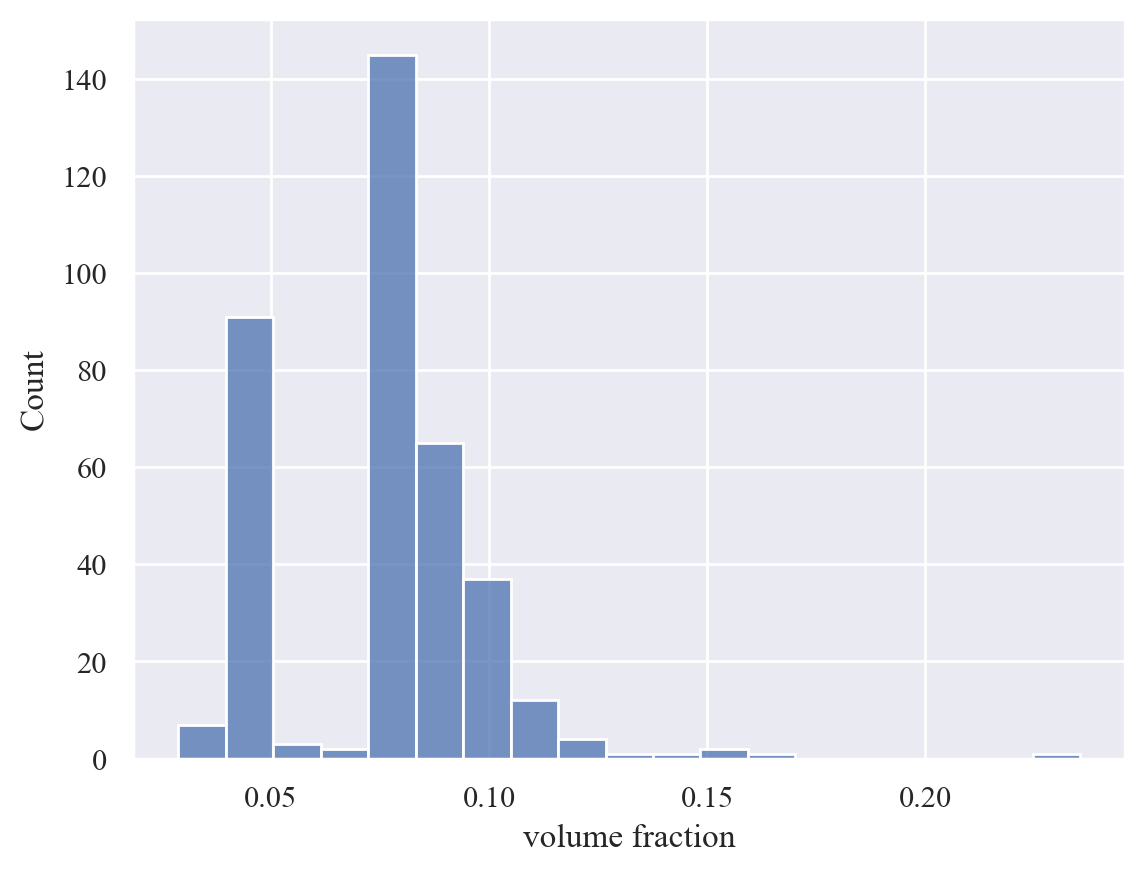

In [18]:
ax = sns.histplot(
    data=df_main,
    x='volume_fraction'
)

ax.set_xlabel('volume fraction')

Test 227 is outlier - long no_mixing_time

8..10 %    271
4..5 %     101
Name: init_volume_fraction_cat, dtype: int64

\begin{tabular}{|l|c|c|}
init_volume_fraction_cat & volume_fraction_binary & 0 \\ \hline
4..5 % & 0 & 101 \\ \hline
8..10 % & 1 & 271 \\ \hline
\end{tabular}



,count,mean,std,min,25%,50%,75%,max
volume_fraction_binary,,,,,,,,
0,101.0,0.043549,0.004731,0.028755,0.040164,0.042889,0.046479,0.067161
1,271.0,0.088288,0.015575,0.037043,0.080000,0.081744,0.092860,0.235561


Text(0, 0.5, 'volume fraction')

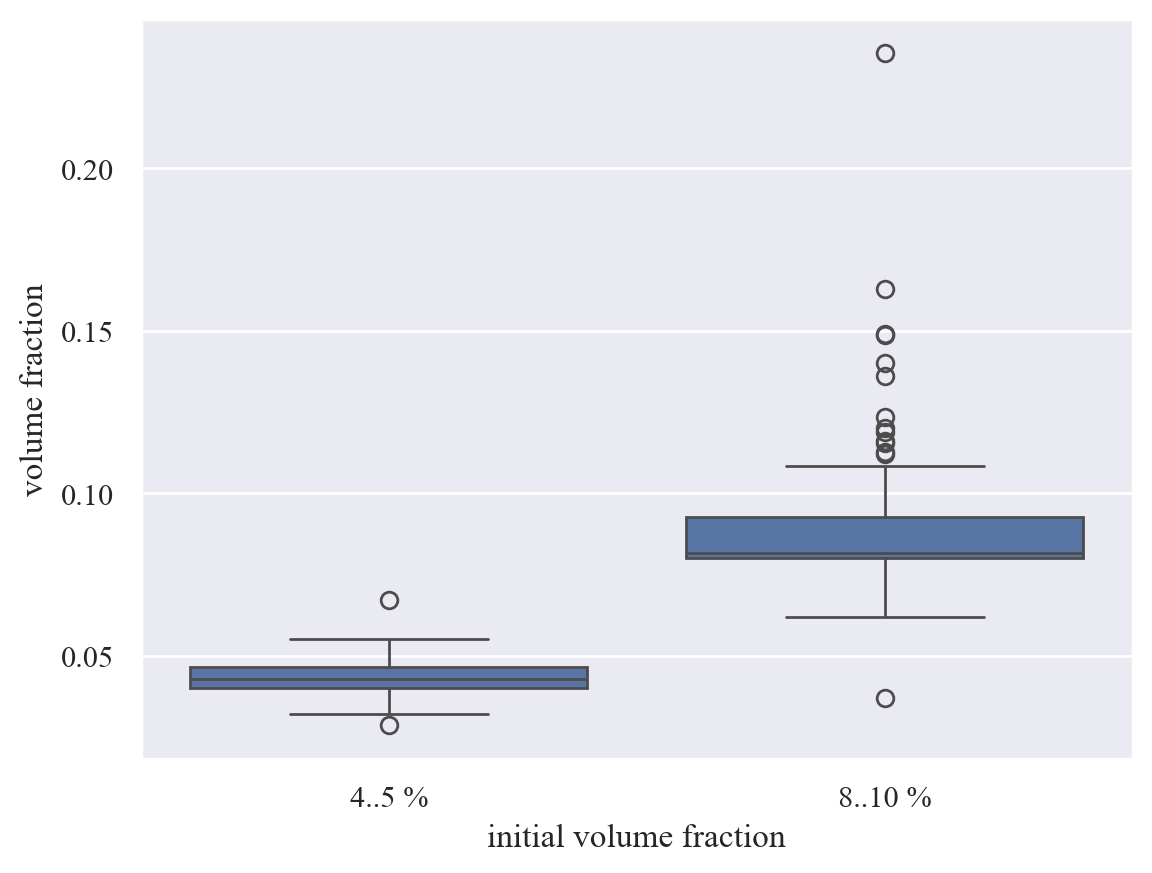

In [19]:
def get_volume_fraction_type(value):
    if value == 1:
        return '8..10 %'
    else:
        return '4..5 %'

df_main['init_volume_fraction_cat'] = df_main['volume_fraction_binary'].apply(get_volume_fraction_type)
display(df_main['init_volume_fraction_cat'].value_counts())

# GET LATEX
df_tex = (
    pd.DataFrame(df_main[['init_volume_fraction_cat', 'volume_fraction_binary']]
    .value_counts(ascending=True))
    .reset_index()
)
# df_tex = df_tex.rename(
#     {
#         'wettability': 'substrate wettability',
#         'wettability_ordinal': 'wettability'
#     },
#     axis=1
# )
# display(df_tex)


latex_code = df_tex.style.hide(axis="index").to_latex(
    # index=False,
    column_format='|l|c|c|',
)

latex_code = latex_code.replace("\\\n", "\\ \hline\n")
print(
    latex_code
)

df_volume_frac = pd.DataFrame(df_main['volume_fraction_binary'].value_counts()).reset_index()

display(
    df_main.groupby(by='volume_fraction_binary')['volume_fraction'].describe()
)

ax = sns.boxplot(
    data=df_main,
    x='init_volume_fraction_cat',
    y='volume_fraction',
    order=['4..5 %', '8..10 %']
)

ax.set_xlabel('initial volume fraction')
ax.set_ylabel('volume fraction')

# display(df_volume_frac)

### Sedimentation Re

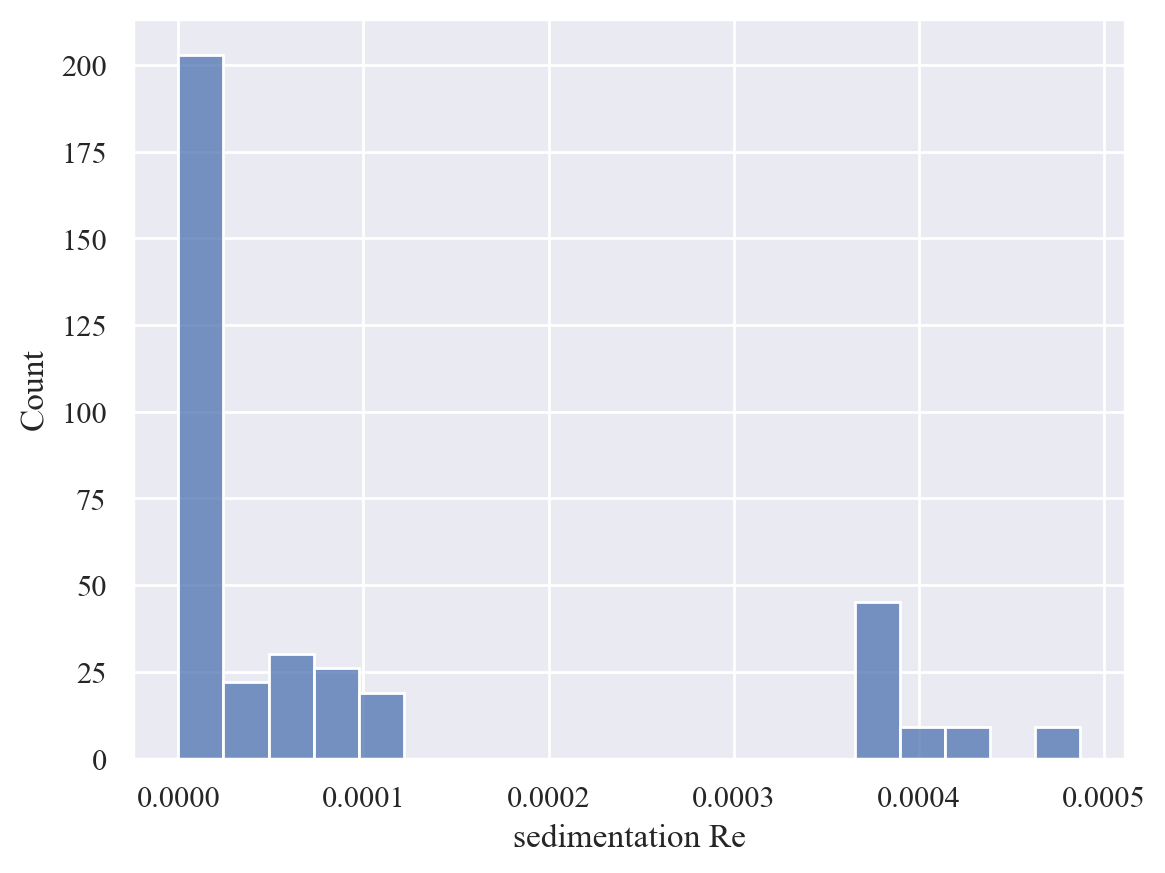

In [20]:
ax = sns.histplot(
    data=df_main,
    x='sedimentation_Re'
)

ax.set_xlabel('sedimentation Re');

### Wettability to ordinal

Change wettability to semi-ordinal feature

In [21]:
print('Wettability before encoding')
print(df_main['wettability'].value_counts())
print()

wettability_dict = {
    'lyophilic': 1,
    'neutral': 0,
    'lyophobic': -1,
}

print('Wettability after encoding')
df_main['wettability_ordinal'] = df_main['wettability'].map(wettability_dict)
print(df_main['wettability_ordinal'].value_counts())

# GET LATEX
df_tex = (
    pd.DataFrame(df_main[['wettability', 'wettability_ordinal']]
    .value_counts())
    .reset_index()
)
df_tex = df_tex.rename(
    {
        'wettability': 'substrate wettability',
        'wettability_ordinal': 'wettability',
        0: 'count'
    },
    axis=1
)
display(df_tex)

latex_code = df_tex.style.hide(axis='index').to_latex(
    column_format='|l|c|c|',
)

latex_code = latex_code.replace("\\\n", "\\ \hline\n")
print(
    latex_code
)

# Drop unnecessary column
df_main['wettability'] = df_main['wettability_ordinal']
df_main = df_main.drop(
    'wettability_ordinal',
    axis=1
)
df_main.info()
print(df_main['wettability'].value_counts())

Wettability before encoding
lyophilic    147
neutral      114
lyophobic    111
Name: wettability, dtype: int64

Wettability after encoding
 1    147
 0    114
-1    111
Name: wettability_ordinal, dtype: int64


,substrate wettability,wettability,count
0,lyophilic,1,147
1,neutral,0,114
2,lyophobic,-1,111


\begin{tabular}{|l|c|c|}
substrate wettability & wettability & count \\ \hline
lyophilic & 1 & 147 \\ \hline
neutral & 0 & 114 \\ \hline
lyophobic & -1 & 111 \\ \hline
\end{tabular}

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 43 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   test                                  372 non-null    int64  
 1   no_fragmentation                      372 non-null    int64  
 2   splashing                             372 non-null    int64  
 3   splashing_spectrum                    372 non-null    int64  
 4   breaking_up                           372 non-null    int64  
 5   rebound                               372 non-null    int64  
 6   one_drop                              372 non-null    int64  
 7   voltage                               372 non-null    float64
 8   long_impulse_duration                

### Particle properties

In [22]:
df_main[['particle_droplet_diameter_ratio', 'particle_liquid_density_ratio']].describe()

,particle_droplet_diameter_ratio,particle_liquid_density_ratio
count,372.000000,372.000000
mean,0.026760,0.994035
std,0.025510,0.261595
min,0.011339,0.381356
25%,0.012604,0.943396
50%,0.013540,1.000000
75%,0.024635,1.016949
max,0.103774,1.864407


## Correlation

In [23]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 43 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   test                                  372 non-null    int64  
 1   no_fragmentation                      372 non-null    int64  
 2   splashing                             372 non-null    int64  
 3   splashing_spectrum                    372 non-null    int64  
 4   breaking_up                           372 non-null    int64  
 5   rebound                               372 non-null    int64  
 6   one_drop                              372 non-null    int64  
 7   voltage                               372 non-null    float64
 8   long_impulse_duration                 372 non-null    int64  
 9   long_impulse_dur_binary               372 non-null    object 
 10  wettability                           372 non-null    int64  
 11  roughness          

In [24]:
impact_labels = ['splashing_spectrum', 'breaking_up', 'rebound']
# Unnecesary to model
generation_features = [
    'one_drop', 
    'voltage', 
    'long_impulse_duration', 
    'long_impulse_dur_binary'
]

features_to_drop = (
    [
        'test', # not informative
        'height', # velocity is more informative
        'particle_diameter_cat', # necessary only for bar visualization
        'init_volume_fraction_cat', # only for plots and stats
    ] 
    + impact_labels
    + generation_features
)

df = df_main.drop(features_to_drop, axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 32 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_fragmentation                      372 non-null    int64  
 1   splashing                             372 non-null    int64  
 2   wettability                           372 non-null    int64  
 3   roughness                             372 non-null    float64
 4   liquid_density                        372 non-null    int64  
 5   surface_tension                       372 non-null    float64
 6   viscosity                             372 non-null    float64
 7   particle_mean_diameter                372 non-null    float64
 8   particle_density                      372 non-null    int64  
 9   volume_fraction                       372 non-null    float64
 10  droplet_diameter                      372 non-null    float64
 11  inclination        

Index(['no fragmentation', 'splashing', 'wettability', 'roughness',
       'liquid density', 'surface tension', 'viscosity',
       'particle mean diameter', 'particle density', 'volume fraction',
       'droplet diameter', 'inclination', 'roughness binary',
       'particle-liquid density ratio', 'volume fraction binary',
       'particle-droplet diameter ratio', 'velocity', 'Re', 'We', 'K',
       'no mixing time', 'init volume fraction', 'sedimentation velocity',
       'sedimentation Re', 'sedimentation Stk', 'sign sedimentation Re',
       'sign sedimentation Stk', 'sign particle droplet diameter ratio',
       'droplet density', 'free fall velocity', 'drag velocity',
       'relative roughness'],
      dtype='object')

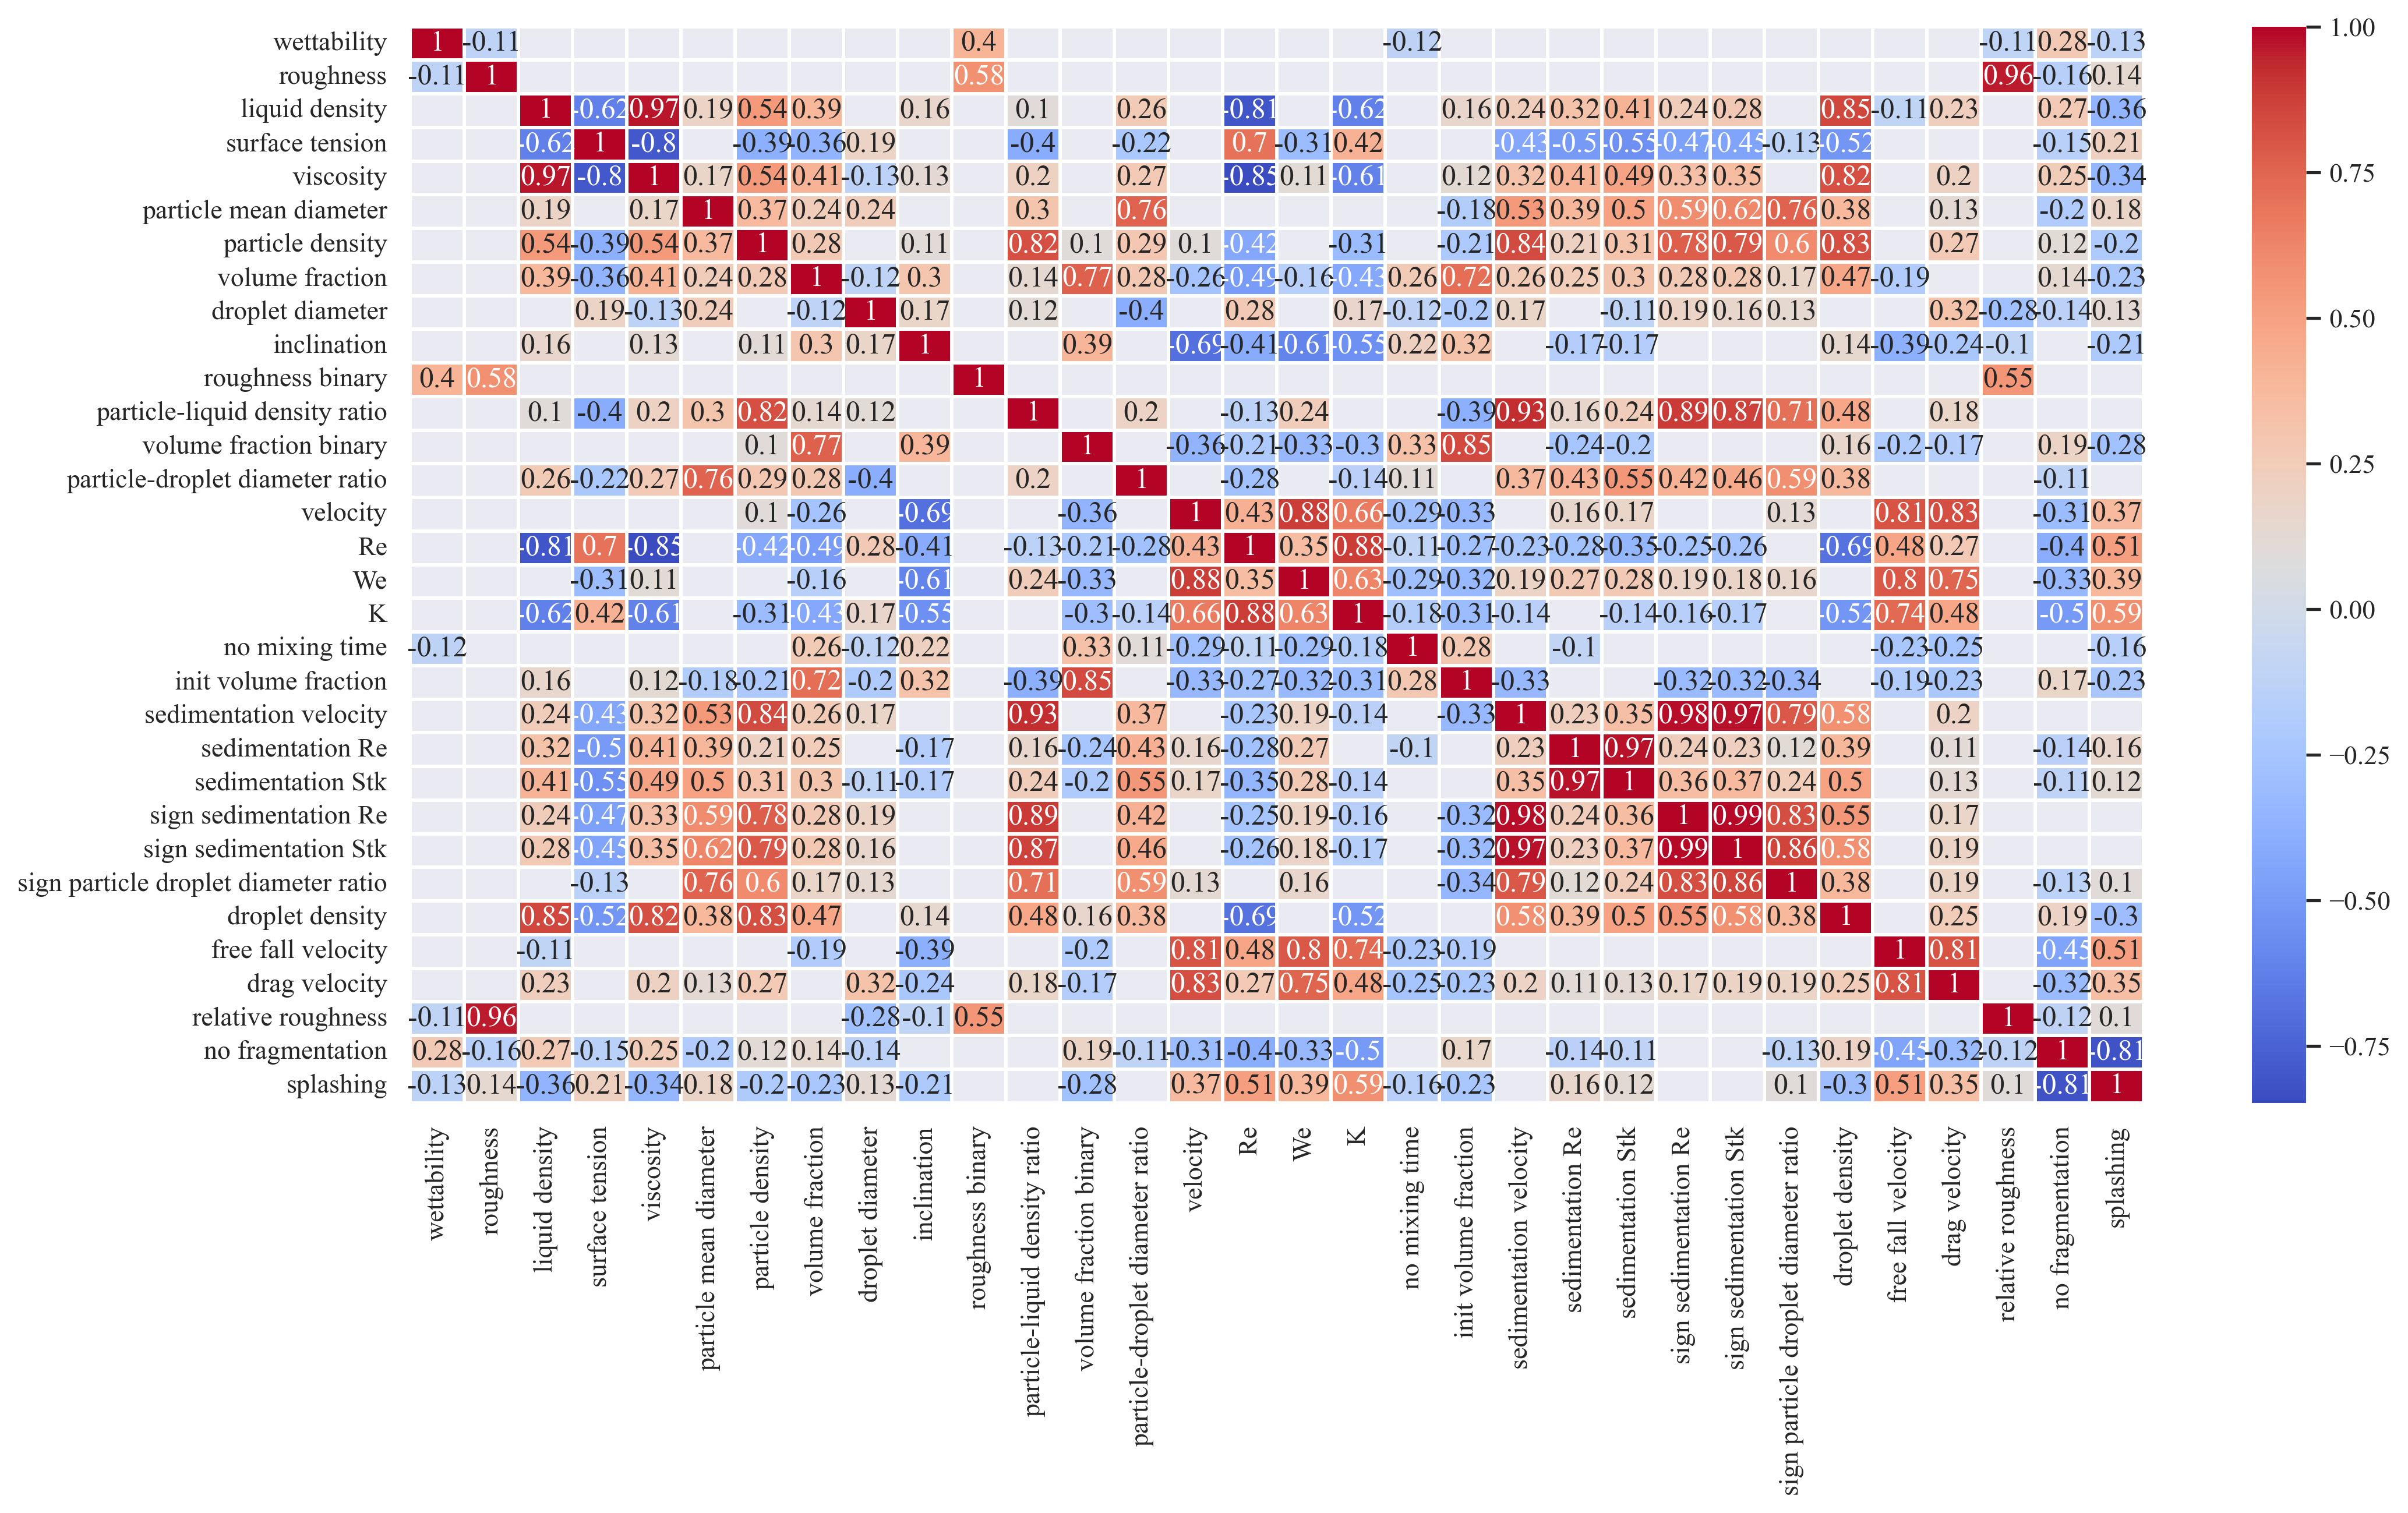

In [25]:
def get_corrmap(
    df, 
    thresh = 0.10,
    triag=False,
    method='spearman',
    ax=None,
    figsize=(12, 12)
):
    corr = df.corr(
        method=method,
        numeric_only=True,
    )
    if ax==None:
        fig, ax = plt.subplots(figsize=figsize)
    if triag:
        inds = np.triu_indices(len(corr), k=1)
        mask = np.zeros(
            corr.shape,
            dtype=bool
        )
        mask[inds] = True
        corr[mask] = np.nan
    if thresh:
        corr = corr[np.abs(corr)>=thresh]
    sns.heatmap(corr, annot=True, cmap='coolwarm', ax=ax, linewidths=1)
    ax.grid(False)


df_plot = df.rename(
    {
        'particle_liquid_density_ratio': 'particle-liquid density ratio',
        'particle_droplet_diameter_ratio': 'particle-droplet diameter ratio',
    },
    axis=1
)

df_plot.columns = df_plot.columns.str.replace('_', ' ')
display(df_plot.columns)

df_plot = pd.concat(
    [
        df_plot.iloc[:,2:],
        df_plot.iloc[:,:2]
    ],
    axis=1
)

fig, ax = plt.subplots(figsize=(16, 8), dpi=300)

get_corrmap(df_plot, triag=False, ax=ax)
plt.savefig(
    Path(
        Path('..', 'results', 'experiments'), 
        f'full_features_corr_map.pdf',
    ),
    bbox_inches='tight',
    dpi=600
)
# ax.set_xticklabels(ax.get_xticklabels(), rotation = 45);

In [26]:
df.dtypes

no_fragmentation                          int64
splashing                                 int64
wettability                               int64
roughness                               float64
liquid_density                            int64
surface_tension                         float64
viscosity                               float64
particle_mean_diameter                  float64
particle_density                          int64
volume_fraction                         float64
droplet_diameter                        float64
inclination                             float64
roughness_binary                          int64
particle_liquid_density_ratio           float64
volume_fraction_binary                    int64
particle_droplet_diameter_ratio         float64
velocity                                float64
Re                                      float64
We                                      float64
K                                       float64
no_mixing_time                          

# Prepare `df_dimless`

Analog of `df_modelling_dimensionless.xlsx`

In [27]:

drag_cols = [
    'droplet_density', # For Re, We we use only liquid density!
    'free_fall_velocity', # No need, since we have actual velocity
    'drag_velocity', # Vertical velocity, no need
    'velocity', # Normal to substrate velocity. It is inside Re, We
]

volume_frac_cols = [
    'no_mixing_time', # If we keep init volume fraction, no mixing time is inside difference with volume fraction
    'sedimentation_velocity', # It is inside sedimentation_Re
    'volume_fraction_binary',
    # 'init_volume_fraction', # No need, since it is not actual volume fraction
    # 'sedimentation_Re', # DO NOT DELETE!
]

roughness_cols = [
    'roughness',
    'roughness_binary',
]

dim_features = [
    'liquid_density',
    'surface_tension',
    'viscosity',
    'particle_mean_diameter',
    'particle_density',
    'droplet_diameter',
]

features_to_drop = (
    drag_cols
    + volume_frac_cols
    + roughness_cols
    + dim_features
)

df_dimless = df.drop(features_to_drop, axis=1)

features = [
    'init_volume_fraction',
    'volume_fraction',
    'sedimentation_Re',
    'sign_sedimentation_Re',
    'sign_sedimentation_Stk',
    'sedimentation_Stk',
    'particle_liquid_density_ratio',
    'particle_droplet_diameter_ratio',
    'sign_particle_droplet_diameter_ratio',
    'wettability',
    'relative_roughness',
    'inclination',
    'Re',
    'We',
    'K',
]

targets = [
    'splashing',
    'no_fragmentation',
]

columns = features + targets

assert len(columns) == len(df_dimless.columns), "Different columns count"

df_dimless = df_dimless[
    (
        features
        + targets
    )
]
df_dimless.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 17 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   init_volume_fraction                  372 non-null    float64
 1   volume_fraction                       372 non-null    float64
 2   sedimentation_Re                      372 non-null    float64
 3   sign_sedimentation_Re                 372 non-null    float64
 4   sign_sedimentation_Stk                372 non-null    float64
 5   sedimentation_Stk                     372 non-null    float64
 6   particle_liquid_density_ratio         372 non-null    float64
 7   particle_droplet_diameter_ratio       372 non-null    float64
 8   sign_particle_droplet_diameter_ratio  372 non-null    float64
 9   wettability                           372 non-null    int64  
 10  relative_roughness                    372 non-null    float64
 11  inclination        

Index(['init volume fraction', 'volume fraction', 'sedimentation Re',
       'sign sedimentation Re', 'sign sedimentation Stk', 'sedimentation Stk',
       'particle-liquid density ratio', 'particle-droplet diameter ratio',
       'sign particle droplet diameter ratio', 'wettability',
       'relative roughness', 'inclination', 'Re', 'We', 'K', 'splashing',
       'no fragmentation'],
      dtype='object')

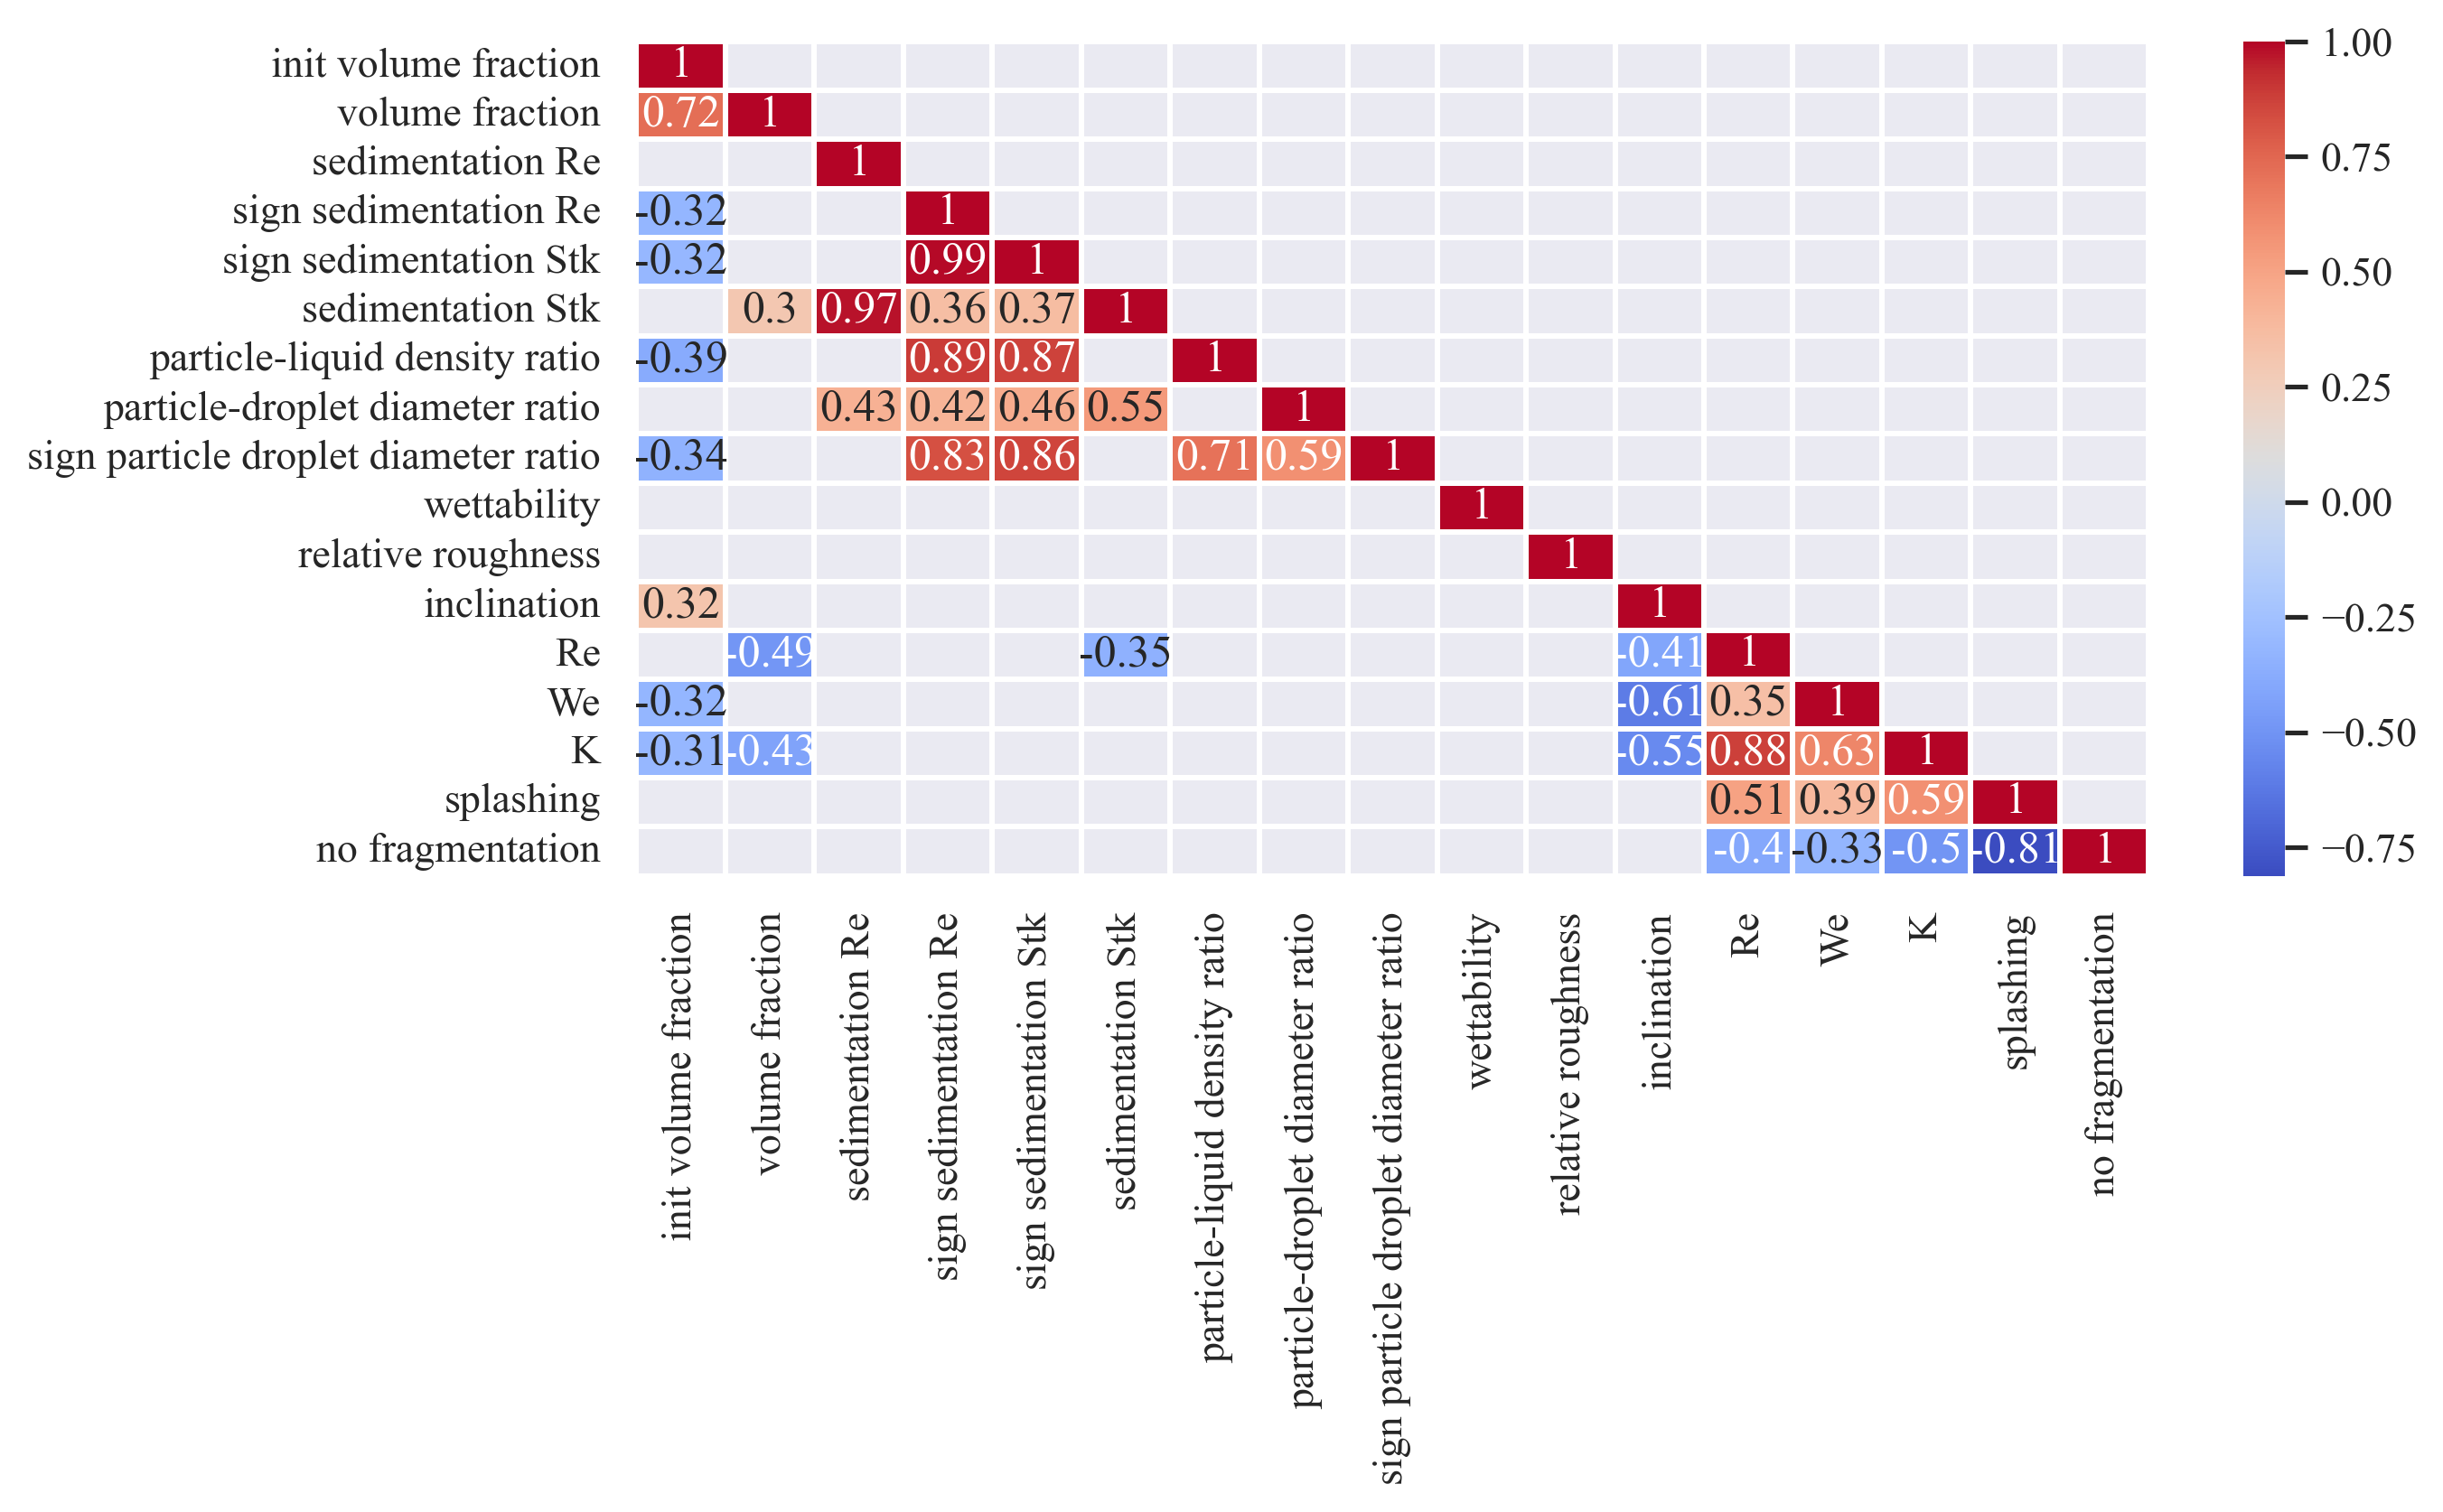

In [28]:
df_plot = df_dimless.rename(
    {
        'particle_liquid_density_ratio': 'particle-liquid density ratio',
        'particle_droplet_diameter_ratio': 'particle-droplet diameter ratio',
    },
    axis=1
)

df_plot.columns = df_plot.columns.str.replace('_', ' ')
display(df_plot.columns)

# df_plot = pd.concat(
#     [
#         df_plot.iloc[:,2:],
#         df_plot.iloc[:,:2]
#     ],
#     axis=1
# )

fig, ax = plt.subplots(figsize=(9, 4), dpi=300)

get_corrmap(df_plot, triag=True, thresh=0.3, ax=ax)
plt.savefig(
    Path(
        Path('..', 'results', 'experiments'), 
        f'dimless_features_corr_map.pdf',
    ),
    bbox_inches='tight',
    dpi=600
)

Maybe, "Re" might be excluted, since it is highly correlated with the "K"
Also, "init volume fraction might be also excluded"

# Save dimless dataset

In [29]:
df_dimless.to_excel(Path(data_root, 'df_dimless.xlsx'), index=False)

# Additional Plots and stats

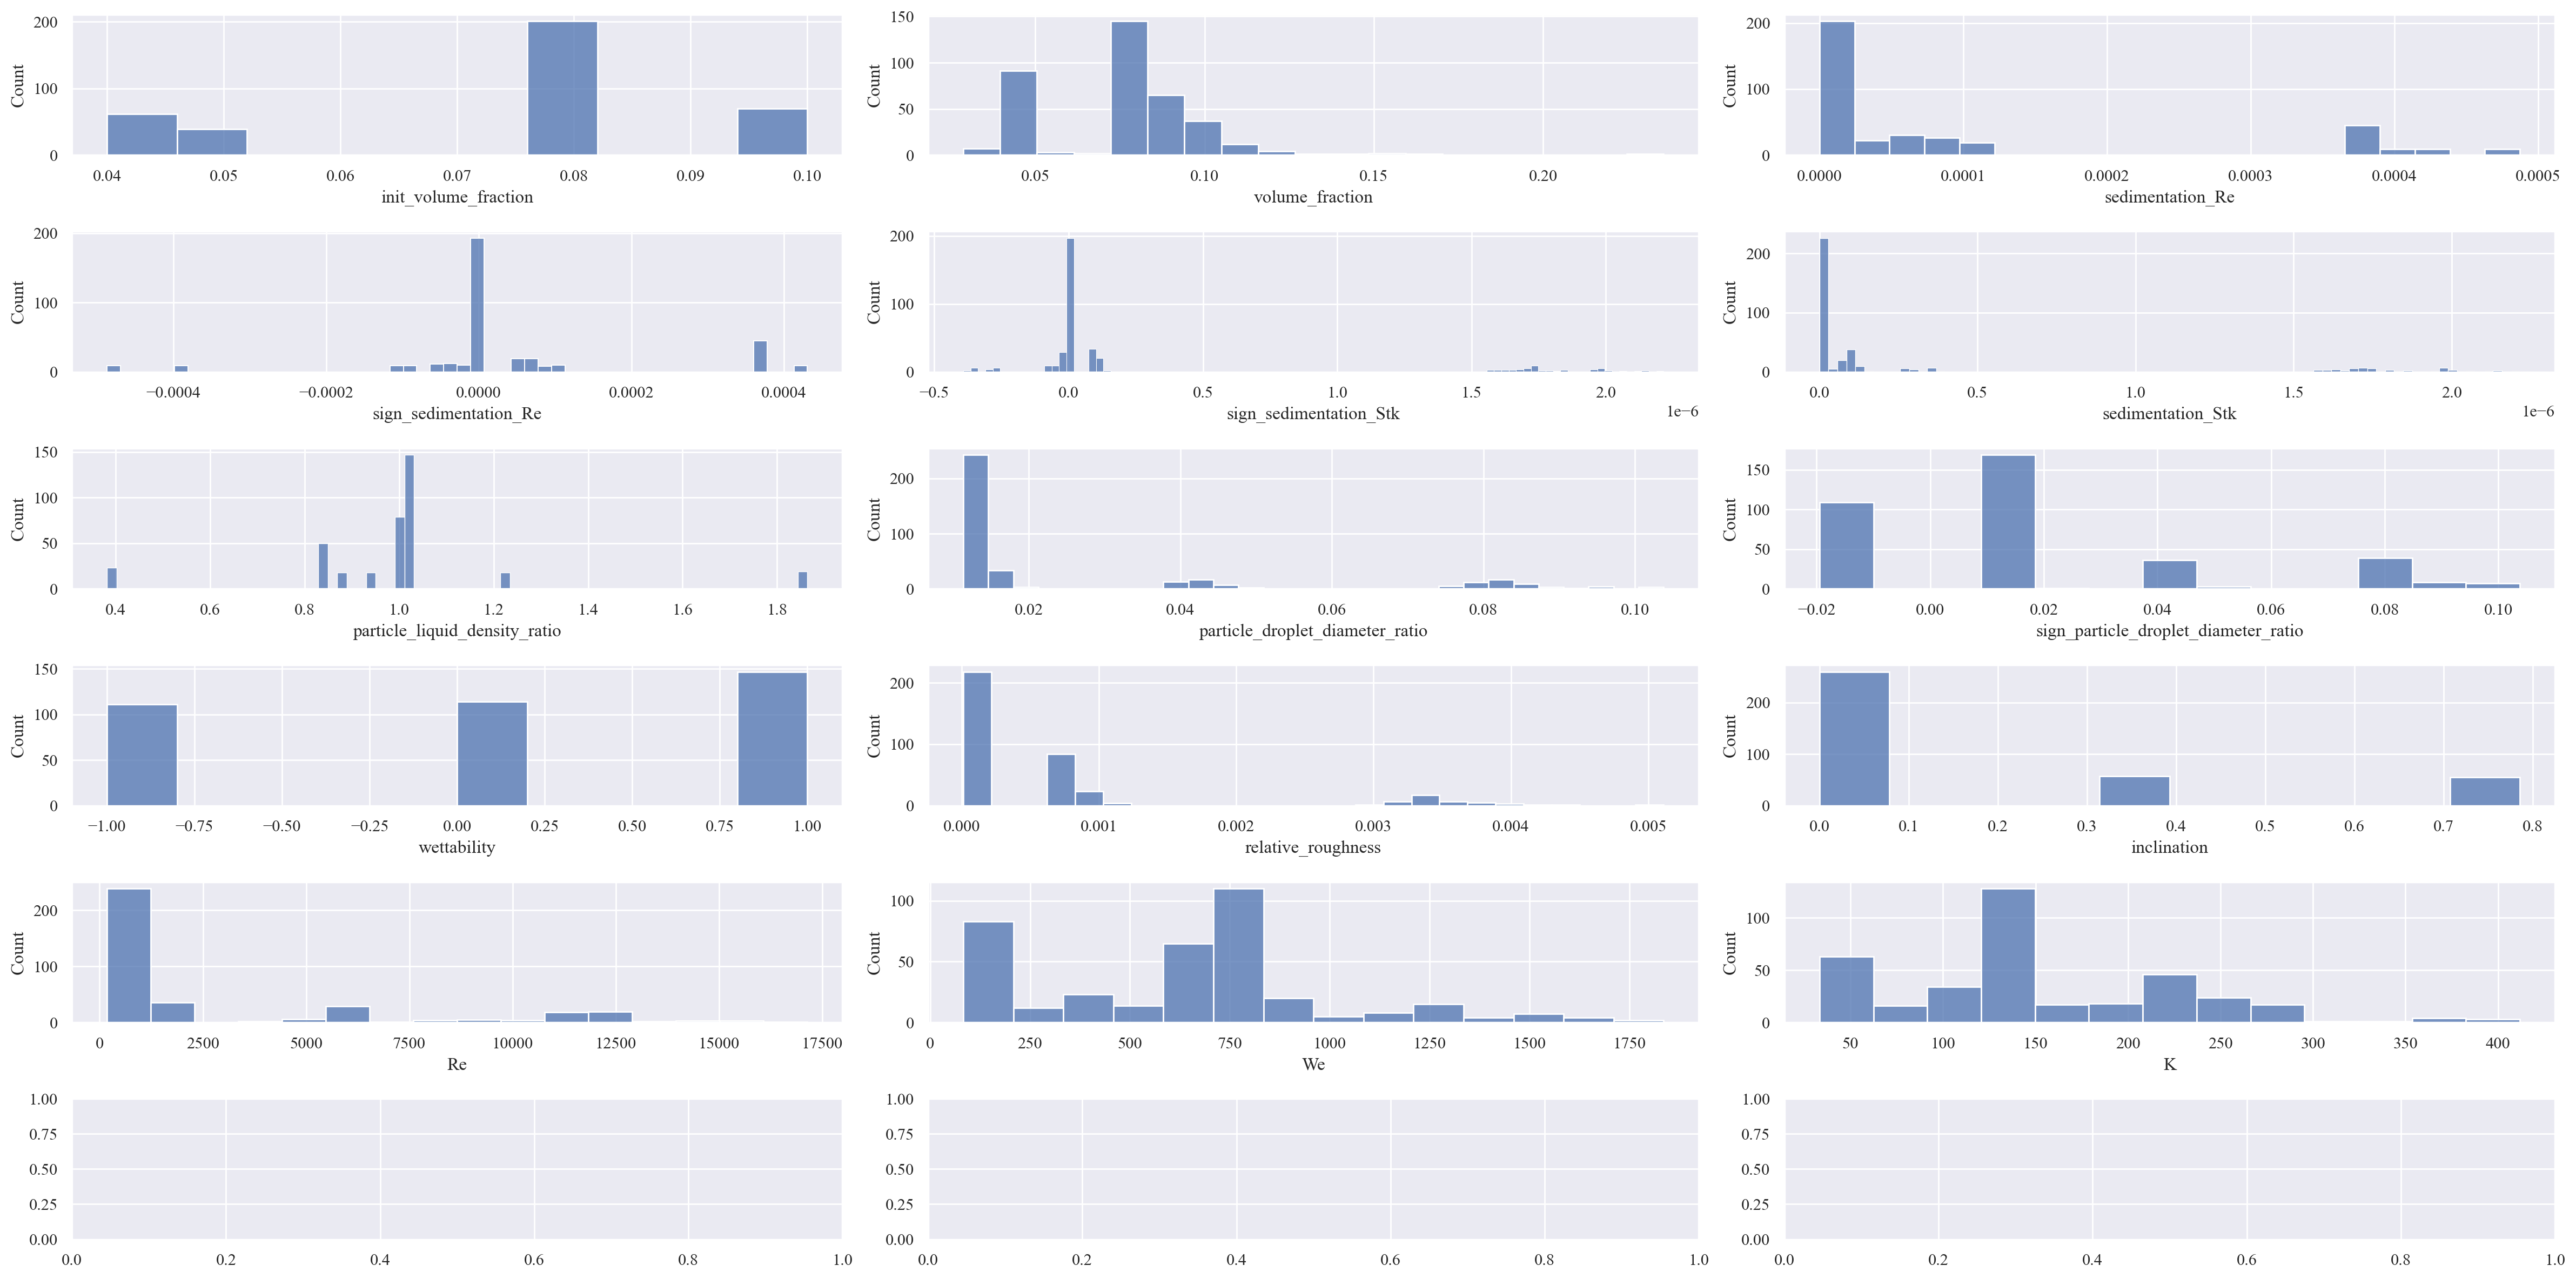

In [30]:
cols = int(np.floor(len(features)**0.5))
scale = 4

fig, axes = plt.subplots(
    len(features)//cols+1, 
    cols, 
    figsize=((len(features)//cols+1)*scale, cols*scale)
)

for feature, ax in zip(features,axes.flat):
    sns.histplot(
        data=df_dimless,
        x=feature,
        ax=ax
    )

fig.tight_layout()